# Regresión logística en Python
## Caso: abandono de producto financiero

**Curso:** Machine Learning en Economía y Finanzas · FCEA · Clase 9 · 2026-2

En este taller el desenlace es **binario**: el cliente `permanece` (0) o `abandona` (1) la relación con el banco. La estimación se realiza mediante un modelo de regresión logística con `statsmodels` (`logit` / `glm` binomial).


Cuaderno para **Colab** o local. El CSV es `abandono_producto_financiero.csv` (ubicado junto al cuaderno en la raíz del repositorio.).

Cada fila es un cliente observado con desenlace observado: `abandono` = 1 (el cliente cerró la relación) o `abandono` = 0 (el cliente permaneció). El modelo estima $P(y=1 \mid x)$ con $y=1$ si `Abandono` = `1`.

**Respuestas — Punto 1**

**1.** La base cruda tiene **14 variables** (10000 clientes). Tras eliminar `numero_fila`, `id_cliente` y `apellido` quedan **11**: 10 variables explicativas y la respuesta `abandono`.

**2.** Hay **6 cuantitativas**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y `salario_estimado`. `numero_productos` es un conteo entero, pero el enunciado lo trata como continua en el logit.

**3.** Hay **5 categóricas**: `pais` y `sexo` (categóricas), `tiene_tarjeta` y `miembro_activo` (binarias 0/1) y la respuesta `abandono`.

**4.** En la fórmula, `C(pais)` y `C(sexo)` hacen que `statsmodels` cree las dummies automáticamente y deje el primer nivel como referencia. Por eso se fija el orden con `pd.Categorical`: así los coeficientes se leen contra Francia y Mujer. `pais` genera 2 dummies y `sexo` genera 1. Las binarias `tiene_tarjeta` y `miembro_activo` ya son 0/1 y entran directamente, sin `C()`. Habría que omitir un nivel por factor para evitar colinealidad perfecta, con más código y más riesgo de error.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
from IPython.display import display

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

CSV = "abandono_producto_financiero.csv"
if not Path(CSV).exists():
    raise FileNotFoundError(
        f"No está {CSV}. Déjelo en la misma carpeta que este cuaderno (raíz del repositorio)."
    )

In [7]:
raw = pd.read_csv(CSV, encoding="utf-8-sig")
raw.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [8]:
raw.tail()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
9995,9996,15606229,Obijiaku,771,Francia,Hombre,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,Francia,Hombre,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,Francia,Mujer,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Alemania,Hombre,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,Francia,Mujer,28,4,130142.79,1,1,0,38190.78,0


In [9]:
print(raw.columns.tolist())
print("shape:", raw.shape)

['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']
shape: (10000, 14)


In [10]:
raw.describe(include="all")

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,Francia,Hombre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


Se eliminan los tres identificadores. `pais` y `sexo` pasan a `category` con los niveles del diccionario **en ese orden**, para que `C(pais)` y `C(sexo)` usen como referencia Francia y Mujer. `abandono` queda como entero 0/1.

In [11]:
df = raw.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

df["pais"] = pd.Categorical(df["pais"], categories=["Francia", "Alemania", "España"])
df["sexo"] = pd.Categorical(df["sexo"], categories=["Mujer", "Hombre"])
df["abandono"] = df["abandono"].astype(int)

print("Referencia de pais:", df["pais"].cat.categories[0])
print("Referencia de sexo:", df["sexo"].cat.categories[0])
print("Valores faltantes en toda la base:", int(df.isna().sum().sum()))
df.dtypes

Referencia de pais: Francia
Referencia de sexo: Mujer
Valores faltantes en toda la base: 0


puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

In [12]:
cuantitativas = ["puntaje_crediticio", "edad", "antiguedad", "saldo", "numero_productos", "salario_estimado"]
categoricas = ["pais", "sexo", "tiene_tarjeta", "miembro_activo", "abandono"]

print("Variables en la base cruda:      ", raw.shape[1])
print("Variables tras eliminar los IDs: ", df.shape[1], "(10 explicativas + la respuesta)")
print("Cuantitativas:                   ", len(cuantitativas), cuantitativas)
print("Categóricas o binarias:          ", len(categoricas), categoricas)

Variables en la base cruda:       14
Variables tras eliminar los IDs:  11 (10 explicativas + la respuesta)
Cuantitativas:                    6 ['puntaje_crediticio', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado']
Categóricas o binarias:           5 ['pais', 'sexo', 'tiene_tarjeta', 'miembro_activo', 'abandono']


**Respuestas — Punto 1**

**1.** La base cruda tiene **14 variables** (10000 clientes). Tras eliminar `numero_fila`, `id_cliente` y `apellido` quedan **11**: 10 variables explicativas y la respuesta `abandono`.

**2.** Hay **6 cuantitativas**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y `salario_estimado`. `numero_productos` es un conteo entero, pero el enunciado lo trata como continua en el logit.

**3.** Hay **5 categóricas**: `pais` y `sexo` (categóricas), `tiene_tarjeta` y `miembro_activo` (binarias 0/1) y la respuesta `abandono`.

**4.** En la fórmula, `C(pais)` y `C(sexo)` hacen que `statsmodels` cree las dummies automáticamente y deje el primer nivel como referencia. Por eso se fija el orden con `pd.Categorical`: así los coeficientes se leen contra Francia y Mujer. `pais` genera 2 dummies y `sexo` genera 1. Las binarias `tiene_tarjeta` y `miembro_activo` ya son 0/1 y entran directamente, sin `C()`. Habría que omitir un nivel por factor para evitar colinealidad perfecta, con más código y más riesgo de error.

# Punto 2. Descriptivo univariado

Conteo, proporción y gráfico de barras.

In [13]:
conteo = df["abandono"].value_counts().sort_index()
prop = df["abandono"].value_counts(normalize=True).sort_index()
pd.DataFrame({"clientes": conteo, "proporcion": prop.round(4), "porcentaje": (prop * 100).round(2)})

,clientes,proporcion,porcentaje
abandono,,,
0,7963,0.7963,79.63
1,2037,0.2037,20.37


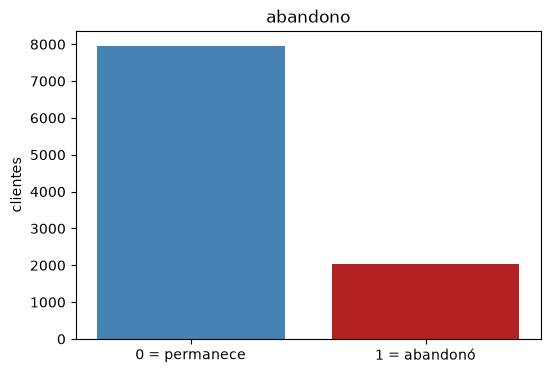

In [14]:
plt.bar(["0 = permanece", "1 = abandonó"], conteo.values, color=["steelblue", "firebrick"])
plt.ylabel("clientes")
plt.title("abandono")
plt.show()

In [15]:
acc_ingenua = 1 - df["abandono"].mean()
print(f"Accuracy de un clasificador que siempre dice 'permanece' (base completa): {acc_ingenua:.4f}")
print(f"Abandonos que detecta: 0 de {int(df['abandono'].sum())}")

Accuracy de un clasificador que siempre dice 'permanece' (base completa): 0.7963
Abandonos que detecta: 0 de 2037


Las variables numéricas: resumen e histogramas.

In [16]:
df[cuantitativas].describe()

,puntaje_crediticio,edad,antiguedad,saldo,numero_productos,salario_estimado
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


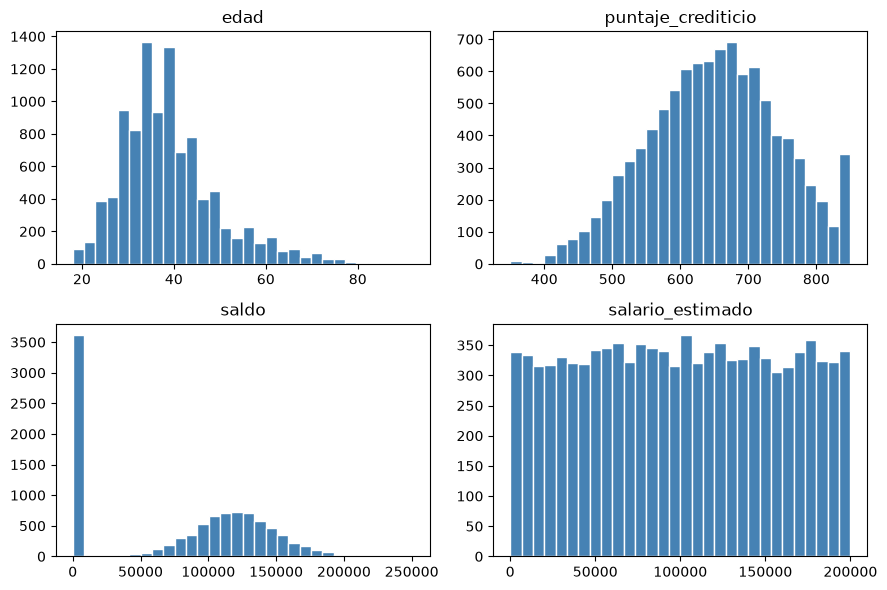

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, col in zip(axes.ravel(), ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Tablas de frecuencia de `pais`, `sexo`, `numero_productos` y `miembro_activo`:

In [18]:
for col in ["pais", "sexo", "numero_productos", "miembro_activo"]:
    n = df[col].value_counts().sort_index()
    pct = (df[col].value_counts(normalize=True).sort_index() * 100).round(2)
    print(f"\n{col}")
    display(pd.DataFrame({"n": n, "%": pct}))


pais


,n,%
pais,,
Francia,5014,50.14
Alemania,2509,25.09
España,2477,24.77



sexo


,n,%
sexo,,
Mujer,4543,45.43
Hombre,5457,54.57



numero_productos


,n,%
numero_productos,,
1,5084,50.84
2,4590,45.90
3,266,2.66
4,60,0.60



miembro_activo


,n,%
miembro_activo,,
0,4849,48.49
1,5151,51.51


El histograma de `saldo` tiene una barra alta en cero. Cuántos clientes tienen saldo 0 y en qué país:

In [19]:
print(f"Clientes con saldo = 0: {(df['saldo'] == 0).sum()} ({(df['saldo'] == 0).mean():.2%})")
(pd.crosstab(df["pais"], df["saldo"] == 0, normalize="index")
   .rename(columns={False: "saldo > 0", True: "saldo = 0"}).round(3))

Clientes con saldo = 0: 3617 (36.17%)


saldo,saldo > 0,saldo = 0
pais,,
Francia,0.518,0.482
Alemania,1.000,0.000
España,0.516,0.484


**Respuesta - Punto 2**

**5**. En la base, el **20,37 %** de los clientes abandonó el producto, es decir, 2037 de los 10.000 clientes. El otro 79,63 % permaneció.

Si hacemos un clasificador que siempre diga que el cliente permanece, tendría una accuracy de **79,63 %**, que a primera vista parece buena. Pero en realidad no identificaría a ninguno de los clientes que abandonó, por lo que su sensibilidad sería 0. Por eso, cuando las clases están desbalanceadas, no es suficiente mirar solamente la accuracy; también debemos revisar otros indicadores, como la sensibilidad y la especificidad.

En general, la edad está más concentrada entre 32 y 44 años, con una mediana de 37 años. Además, el 36,17 % tiene un saldo de 0. La mayoría de los clientes tiene 1 o 2 productos, con 5084 y 4590 clientes, respectivamente; mientras que son pocos los que tienen 3 o 4 productos.

# Punto 3. Bivariado con la respuesta

Distribución de `edad`, `saldo` y `puntaje_crediticio` según `abandono`:

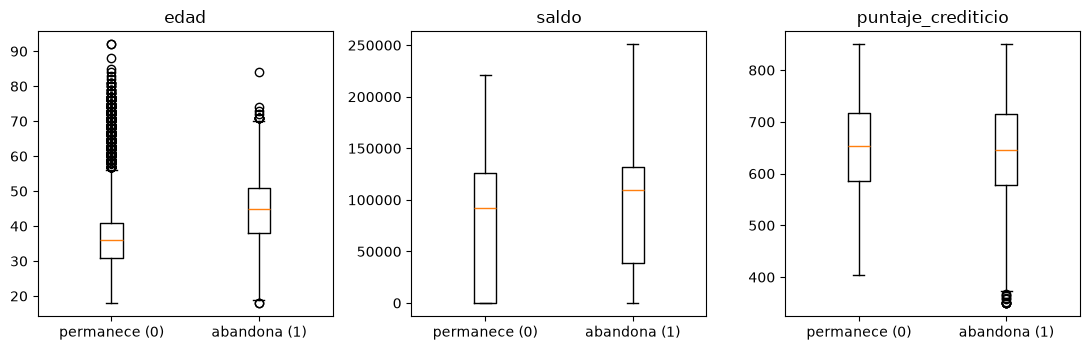

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, col in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [df.loc[df["abandono"] == g, col] for g in [0, 1]]
    ax.boxplot(grupos)
    ax.set_xticklabels(["permanece (0)", "abandona (1)"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [21]:
df.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].agg(["median", "mean"]).round(1)

edad           saldo          puntaje_crediticio       
         median  mean    median     mean             median   mean
abandono                                                          
0          36.0  37.4   92072.7  72745.3              653.0  651.9
1          45.0  44.8  109349.3  91108.5              646.0  645.4

La edad no parece afectar el abandono de forma lineal. Tasa de abandono por tramos de edad:

In [22]:
tramo = pd.cut(df["edad"], bins=[17, 30, 40, 50, 60, 100], labels=["18-30", "31-40", "41-50", "51-60", "61+"])
df.groupby(tramo, observed=True)["abandono"].agg(clientes="size", tasa_abandono="mean").round(4)

,clientes,tasa_abandono
edad,,
18-30,1968,0.0752
31-40,4451,0.1209
41-50,2320,0.3397
51-60,797,0.5621
61+,464,0.2478


Tablas cruzadas y ji-cuadrado de `abandono` contra `miembro_activo`, `numero_productos` y `pais`. La columna `tasa_abandono` es la fracción de la fila que abandonó.

In [23]:
def cruzar(col):
    tab = pd.crosstab(df[col], df["abandono"])
    chi2_val, p, dof, _ = stats.chi2_contingency(tab)
    tab["tasa_abandono"] = (tab[1] / (tab[0] + tab[1])).round(4)
    display(tab)
    print(f"{col}: chi2 = {chi2_val:.1f} · gl = {dof} · p = {p:.3g}\n")

cruzar("miembro_activo")

abandono,0,1,tasa_abandono
miembro_activo,,,
0,3547,1302,0.2685
1,4416,735,0.1427


miembro_activo: chi2 = 243.0 · gl = 1 · p = 8.79e-55



In [24]:
cruzar("numero_productos")

abandono,0,1,tasa_abandono
numero_productos,,,
1,3675,1409,0.2771
2,4242,348,0.0758
3,46,220,0.8271
4,0,60,1.0000


numero_productos: chi2 = 1503.6 · gl = 3 · p = 0



In [25]:
cruzar("pais")

abandono,0,1,tasa_abandono
pais,,,
Francia,4204,810,0.1615
Alemania,1695,814,0.3244
España,2064,413,0.1667


pais: chi2 = 301.3 · gl = 2 · p = 3.83e-66



Para comparar la **fuerza** de la relación (el valor $p$ con $n=10000$ es muy pequeño casi siempre), se usa la V de Cramér en las categóricas y la correlación con `abandono` en las continuas:

In [26]:
def cramers_v(col):
    tab = pd.crosstab(df[col], df["abandono"])
    chi2_val = stats.chi2_contingency(tab)[0]
    return np.sqrt(chi2_val / (tab.values.sum() * (min(tab.shape) - 1)))

v = pd.Series({c: cramers_v(c) for c in ["numero_productos", "pais", "miembro_activo", "sexo", "tiene_tarjeta"]})
print("V de Cramér (categóricas):")
display(v.sort_values(ascending=False).round(3))

print("Correlación con abandono (continuas):")
display(df[["edad", "saldo", "puntaje_crediticio", "antiguedad", "salario_estimado", "abandono"]]
        .corr()["abandono"].drop("abandono").sort_values(key=abs, ascending=False).round(3))

V de Cramér (categóricas):


numero_productos    0.388
pais                0.174
miembro_activo      0.156
sexo                0.106
tiene_tarjeta       0.007
dtype: float64

Correlación con abandono (continuas):


edad                  0.285
saldo                 0.119
puntaje_crediticio   -0.027
antiguedad           -0.014
salario_estimado      0.012
Name: abandono, dtype: float64

In [27]:
cruzar("sexo")
cruzar("tiene_tarjeta")

abandono,0,1,tasa_abandono
sexo,,,
Mujer,3404,1139,0.2507
Hombre,4559,898,0.1646


sexo: chi2 = 112.9 · gl = 1 · p = 2.25e-26



abandono,0,1,tasa_abandono
tiene_tarjeta,,,
0,2332,613,0.2081
1,5631,1424,0.2018


tiene_tarjeta: chi2 = 0.5 · gl = 1 · p = 0.492



**Respuestas — Punto 3**

**6.** Quien abandona es **mayor**: la mediana de edad es **45** años frente a **36** de quien permanece, y en el diagrama de cajas y bigotes la caja del grupo «abandona» está desplazada hacia arriba. La relación no es lineal: la tasa de abandono sube de 7.5 % (18–30) a 12.1 % (31–40), 34.0 % (41–50) y 56.2 % (51–60), y cae a 24.8 % en mayores de 60.

**7.** El `saldo` es algo **mayor** entre quienes abandonan (mediana 109349 frente a 92073). El `puntaje_crediticio` es prácticamente igual (mediana 646 frente a 653): la diferencia es pequeña frente a la dispersión, así que por sí solo no discrimina.

**8.** Sí. Entre los clientes **inactivos** abandona el **26.85 %**; entre los **activos**, el **14.27 %**, casi la mitad. La asociación es significativa (chi² = 243.0, gl = 1, p ≈ 9e-55).

**9.** **No.** La relación no es monótona: abandona el 27.7 % con 1 producto, baja a **7.6 % con 2**, pero sube a **82.7 % con 3** y a **100 % con 4**. Tener más productos no protege siempre; pasar de 1 a 2 se asocia con menos abandono, pero 3 o más se asocia con muchísimo más (chi² = 1503.6, gl = 3, p ≈ 0).

**10.** La asociación más fuerte es la de **`numero_productos`** (V de Cramér = 0.388, muy por encima del resto), seguida de `pais` (0.174) y `miembro_activo` (0.156); `sexo` (0.106) es más débil y `tiene_tarjeta` (0.007, p = 0.49) no muestra relación. Entre las continuas, la mayor correlación es la de **`edad`** (0.285); `saldo` (0.119) es baja y las demás son casi nulas.

# Punto 4. De la recta al logit

Una $x$ continua (`edad`) y una respuesta 0/1. Primero `smf.ols` (modelo lineal de probabilidad), después `smf.logit`, como en la Clase 8. Se usa toda la base.

## OLS con $y$ 0/1

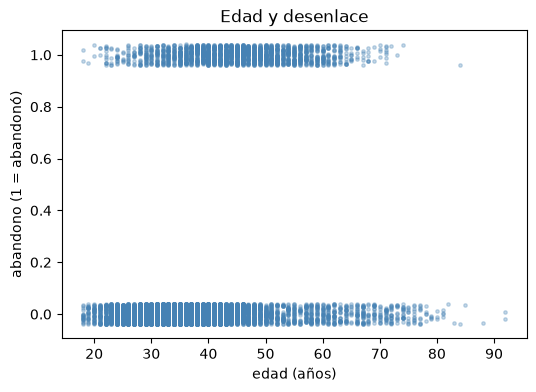

In [28]:
rng = np.random.default_rng(1)
y_jit = df["abandono"] + rng.uniform(-0.04, 0.04, len(df))

plt.scatter(df["edad"], y_jit, c="steelblue", s=6, alpha=0.3)
plt.xlabel("edad (años)")
plt.ylabel("abandono (1 = abandonó)")
plt.title("Edad y desenlace")
plt.show()

In [29]:
ols = smf.ols("abandono ~ edad", data=df).fit()
print(ols.params)

Intercept   -0.222782
edad         0.010957
dtype: float64


In [30]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:               abandono   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     886.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.24e-186
Time:                        16:05:57   Log-Likelihood:                -4670.4
No. Observations:               10000   AIC:                             9345.
Df Residuals:                    9998   BIC:                             9359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2228      0.015    -15.014      0.0

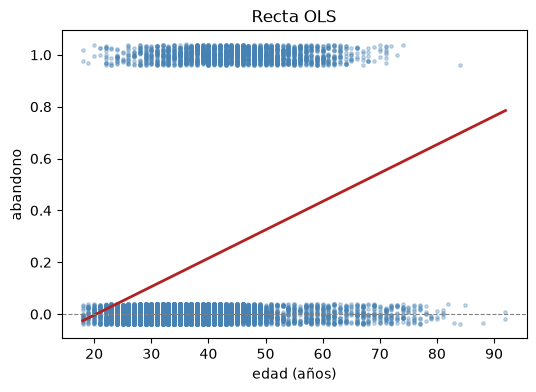

In [31]:
x_line = np.linspace(df["edad"].min(), df["edad"].max(), 50)

plt.scatter(df["edad"], y_jit, c="steelblue", s=6, alpha=0.3)
plt.plot(x_line, ols.params["Intercept"] + ols.params["edad"] * x_line, color="firebrick", lw=2)
plt.axhline(0, color="gray", lw=0.8, ls="--")
plt.xlabel("edad (años)")
plt.ylabel("abandono")
plt.title("Recta OLS")
plt.show()

¿Se queda la recta dentro de $[0,1]$? Se cuentan los valores ajustados fuera de rango y se busca en qué edad la recta cruza 0 y 1:

In [32]:
print("Valores ajustados < 0:", int((ols.fittedvalues < 0).sum()), "| mínimo:", round(ols.fittedvalues.min(), 4))
print("Valores ajustados > 1:", int((ols.fittedvalues > 1).sum()), "| máximo:", round(ols.fittedvalues.max(), 4))
print("Edad en que la recta cruza 0:", round(-ols.params["Intercept"] / ols.params["edad"], 1))
print("Edad en que la recta cruza 1:", round((1 - ols.params["Intercept"]) / ols.params["edad"], 1))
print("Valor OLS a los 40 años:", round(ols.params["Intercept"] + ols.params["edad"] * 40, 4))

Valores ajustados < 0: 89 | mínimo: -0.0255
Valores ajustados > 1: 0 | máximo: 0.7853
Edad en que la recta cruza 0: 20.3
Edad en que la recta cruza 1: 111.6
Valor OLS a los 40 años: 0.2155


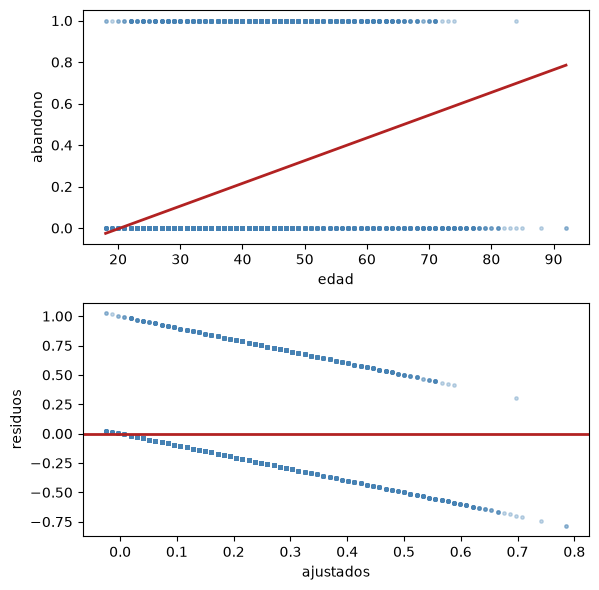

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))
axes[0].scatter(df["edad"], df["abandono"], c="steelblue", s=6, alpha=0.3)
axes[0].plot(x_line, ols.params["Intercept"] + ols.params["edad"] * x_line, color="firebrick", lw=2)
axes[0].set_xlabel("edad")
axes[0].set_ylabel("abandono")
axes[1].scatter(ols.fittedvalues, ols.resid, c="steelblue", s=6, alpha=0.3)
axes[1].axhline(0, color="firebrick", lw=2)
axes[1].set_xlabel("ajustados")
axes[1].set_ylabel("residuos")
plt.tight_layout()
plt.show()

En este ajuste:

1. El valor ajustado de OLS no está restringido a $[0,1]$.
2. Los residuos se concentran en **dos bandas** (una para $y=0$ y otra para $y=1$), porque $y$ es binaria.

## El logit simple

Misma $x$, estimada con `smf.logit` (liga logit):

In [38]:
fit = smf.logit("abandono ~ edad", data=df).fit(disp=False)
print(fit.params)

Intercept   -3.928603
edad         0.062945
dtype: float64


In [39]:
print(fit.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.07505
Time:                        16:08:16   Log-Likelihood:                -4675.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                5.077e-167
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9286      0.103    -38.096      0.000      -4.131      -3.726
edad           0.0629      0.002     26.614      0.000       0.058       0.068


In [40]:
pd.DataFrame({"coef (log-odds)": fit.params, "odds ratio": np.exp(fit.params)})

,coef (log-odds),odds ratio
Intercept,-3.928603,0.019671
edad,0.062945,1.064968


Los coeficientes están en **log-odds**. `np.exp(params)` los pasa a odds ratios: $>1$ sube las odds de abandonar; $<1$ las baja.

De log-odds a probabilidad para un cliente de 40 años:

In [41]:
b0 = fit.params["Intercept"]
b1 = fit.params["edad"]
eta = b0 + b1 * 40
odds = np.exp(eta)
p = odds / (1 + odds)
print(pd.Series({"log_odds": eta, "odds": odds, "P_abandono": p}))

print("\nChequeo con predict:", round(float(fit.predict(pd.DataFrame({"edad": [40]})).iloc[0]), 4))
print("OR por cada 10 años adicionales:", round(float(np.exp(10 * b1)), 3))

log_odds     -1.410810
odds          0.243946
P_abandono    0.196106
dtype: float64

Chequeo con predict: 0.1961
OR por cada 10 años adicionales: 1.877


La curva en S: `predict` devuelve $P(\text{abandono}=1)$, siempre en $(0,1)$. Se superpone la recta OLS para el contraste.

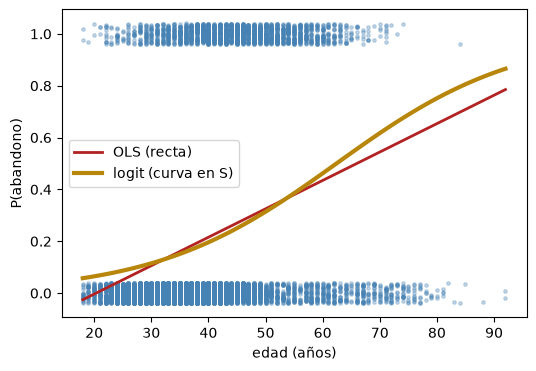

In [42]:
grid = pd.DataFrame({"edad": np.linspace(df["edad"].min(), df["edad"].max(), 80)})
grid["p"] = fit.predict(grid)

plt.scatter(df["edad"], y_jit, c="steelblue", s=6, alpha=0.3)
plt.plot(x_line, ols.params["Intercept"] + ols.params["edad"] * x_line, color="firebrick", lw=2, label="OLS (recta)")
plt.plot(grid["edad"], grid["p"], color="darkgoldenrod", lw=3, label="logit (curva en S)")
plt.xlabel("edad (años)")
plt.ylabel("P(abandono)")
plt.legend()
plt.show()

**Respuestas — Punto 4**

**11.** La recta de OLS no se puede interpretar directamente como una probabilidad porque puede dar valores menores que 0 o mayores que 1, mientras que una probabilidad siempre debe estar entre 0 y 1. En este caso, incluso da valores negativos para algunos clientes de 18 a 20 años. Además, OLS supone que el efecto de la edad es constante, es decir, que cada año aumenta la predicción en la misma cantidad. Por eso, para una variable que solo puede tomar 0 o 1, el logit es más adecuado, ya que sus predicciones siempre quedan entre 0 y 1.

**12.** En el logit simple, el intercepto es −3.9286, el coeficiente de edad es 0.0629 y el odds ratio es 1.065. Esto quiere decir que, por cada año adicional de edad, las odds de abandonar aumentan aproximadamente un 6,5 %. En otras palabras, dentro de los datos de esta base, a mayor edad, mayor es la probabilidad de abandono.

**13.** Para un cliente de 40 años, el modelo estima una probabilidad de abandono de 0.1961, es decir, aproximadamente 19,6 %. Este es el valor que obtenemos al usar predict con el modelo logit simple.

# Punto 5. Varios modelos y odds ratios

## Partición 70 / 30

In [43]:
rng = np.random.default_rng(8)
n = len(df)
n_train = int(round(0.7 * n))
train_pos = rng.choice(n, size=n_train, replace=False)
mask = np.zeros(n, dtype=bool)
mask[train_pos] = True
Train_Data = df.iloc[mask].copy()
Test_Data = df.iloc[~mask].copy()

print("Train:", Train_Data.shape, "| Test:", Test_Data.shape)
print(f"Tasa de abandono - base: {df['abandono'].mean():.4f} | train: {Train_Data['abandono'].mean():.4f} | test: {Test_Data['abandono'].mean():.4f}")

Train: (7000, 11) | Test: (3000, 11)
Tasa de abandono - base: 0.2037 | train: 0.2067 | test: 0.1967


In [44]:
pd.DataFrame({"train": Train_Data["abandono"].value_counts().sort_index(),
              "test": Test_Data["abandono"].value_counts().sort_index()})

,train,test
abandono,,
0,5553,2410
1,1447,590


## Varios logits
**fit1**: solo `edad`.

In [45]:
fit1 = smf.logit("abandono ~ edad", data=Train_Data).fit(disp=False)
print(fit1.params)
print("AIC:", round(fit1.aic, 2))

Intercept   -3.970683
edad         0.064415
dtype: float64
AIC: 6587.91


**fit2**: `edad` y `puntaje_crediticio`.

---

In [47]:
fit2 = smf.logit("abandono ~ edad + puntaje_crediticio", data=Train_Data).fit(disp=False)
print(fit2.params)
print("AIC:", round(fit2.aic, 2))

Intercept            -3.369084
edad                  0.064496
puntaje_crediticio   -0.000933
dtype: float64
AIC: 6581.41


**fit3**: sumamos `C(sexo)`. Referencia: Mujer.

In [48]:
fit3 = smf.logit("abandono ~ edad + puntaje_crediticio + C(sexo)", data=Train_Data).fit(disp=False)
print(fit3.params)
print("AIC:", round(fit3.aic, 2))

Intercept            -3.080367
C(sexo)[T.Hombre]    -0.574074
edad                  0.064700
puntaje_crediticio   -0.000946
dtype: float64
AIC: 6498.0


**fit4**: sumamos `C(pais)`. El factor tiene tres niveles; `patsy` deja Francia como referencia y estima Alemania y España.

In [49]:
fit4 = smf.logit("abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais)", data=Train_Data).fit(disp=False)
print(fit4.params)
print("AIC:", round(fit4.aic, 2))

Intercept             -3.365614
C(sexo)[T.Hombre]     -0.555916
C(pais)[T.Alemania]    0.905477
C(pais)[T.España]      0.037320
edad                   0.065593
puntaje_crediticio    -0.001011
dtype: float64
AIC: 6327.76


**fit5**: sumamos `saldo`, `numero_productos` y `miembro_activo`.

In [51]:
fit5 = smf.logit(
    "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) + saldo + numero_productos + miembro_activo",
    data=Train_Data,
).fit(disp=False)
print(fit5.params)
print("AIC:", round(fit5.aic, 2))

Intercept             -3.257274
C(sexo)[T.Hombre]     -0.554657
C(pais)[T.Alemania]    0.790676
C(pais)[T.España]      0.053364
edad                   0.075017
puntaje_crediticio    -0.000867
saldo                  0.000003
numero_productos      -0.190819
miembro_activo        -1.092294
dtype: float64
AIC: 6021.81


**fit6**: el conjunto del diccionario (suma `antiguedad`, `tiene_tarjeta` y `salario_estimado`).

In [52]:
fit6 = smf.logit(
    "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) + saldo + numero_productos + miembro_activo"
    " + antiguedad + tiene_tarjeta + salario_estimado",
    data=Train_Data,
).fit(disp=False)
print(fit6.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6988
Method:                           MLE   Df Model:                           11
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1594
Time:                        16:14:01   Log-Likelihood:                -2998.3
converged:                       True   LL-Null:                       -3567.0
Covariance Type:            nonrobust   LLR p-value:                4.944e-237
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.2554      0.293    -11.111      0.000      -3.830      -2.681
C(sexo)[T.Hombre]      -0.5511      0.065     -8.466      0.000      -0.679      -0.424
C(pais)[T.Aleman

AIC de fit1 a fit6 (menor es mejor). También se compara fit6 contra fit5.

In [53]:
fits = {"fit1": fit1, "fit2": fit2, "fit3": fit3, "fit4": fit4, "fit5": fit5, "fit6": fit6}
comparacion = pd.DataFrame({
    "parametros": {k: int(f.df_model) + 1 for k, f in fits.items()},
    "AIC": {k: f.aic for k, f in fits.items()},
    "log-lik": {k: f.llf for k, f in fits.items()},
    "pseudo R2": {k: f.prsquared for k, f in fits.items()},
})
comparacion["dif. AIC vs. anterior"] = comparacion["AIC"].diff()
display(comparacion.round(4))

lr = 2 * (fit6.llf - fit5.llf)
gl = int(fit6.df_model - fit5.df_model)
print(f"\nRazón de verosimilitud fit6 vs fit5: LR = {lr:.3f} · gl = {gl} · p = {stats.chi2.sf(lr, gl):.4f}")

,parametros,AIC,log-lik,pseudo R2,dif. AIC vs. anterior
fit1,2,6587.9137,-3291.9569,0.0771,NaN
fit2,3,6581.4147,-3287.7073,0.0783,-6.4991
fit3,4,6497.9951,-3244.9975,0.0903,-83.4196
fit4,6,6327.7609,-3157.8805,0.1147,-170.2341
fit5,9,6021.8148,-3001.9074,0.1584,-305.9461
fit6,12,6020.5700,-2998.2850,0.1594,-1.2447



Razón de verosimilitud fit6 vs fit5: LR = 7.245 · gl = 3 · p = 0.0645


# 5.1 Modelo de trabajo

Se usa *fit5* como modelo de trabajo (logit_fits) para predict en test. Se justifica con AIC, parsimonia y valores $p$.

In [54]:
logit_fits = smf.logit(
    "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) + saldo + numero_productos + miembro_activo",
    data=Train_Data,
).fit(disp=False)
print(logit_fits.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6991
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1584
Time:                        16:14:53   Log-Likelihood:                -3001.9
converged:                       True   LL-Null:                       -3567.0
Covariance Type:            nonrobust   LLR p-value:                1.165e-238
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.2573      0.277    -11.759      0.000      -3.800      -2.714
C(sexo)[T.Hombre]      -0.5547      0.065     -8.527      0.000      -0.682      -0.427
C(pais)[T.Aleman

In [55]:
logit_fits.pvalues.round(4)

Intercept              0.0000
C(sexo)[T.Hombre]      0.0000
C(pais)[T.Alemania]    0.0000
C(pais)[T.España]      0.5266
edad                   0.0000
puntaje_crediticio     0.0098
saldo                  0.0000
numero_productos       0.0009
miembro_activo         0.0000
dtype: float64

Las dummies se leen contra *Francia* y *Mujer*.

In [56]:
ci = np.exp(logit_fits.conf_int())
or_tab = pd.DataFrame({
    "coef": logit_fits.params,
    "OR": np.exp(logit_fits.params),
    "IC95_inf": ci[0],
    "IC95_sup": ci[1],
    "p": logit_fits.pvalues,
})
or_tab.round(5)

,coef,OR,IC95_inf,IC95_sup,p
Intercept,-3.25727,0.03849,0.02237,0.06625,0.00000
C(sexo)[T.Hombre],-0.55466,0.57427,0.50553,0.65236,0.00000
C(pais)[T.Alemania],0.79068,2.20489,1.88151,2.58384,0.00000
C(pais)[T.España],0.05336,1.05481,0.89421,1.24427,0.52661
edad,0.07502,1.07790,1.07134,1.08450,0.00000
puntaje_crediticio,-0.00087,0.99913,0.99848,0.99979,0.00976
saldo,0.00000,1.00000,1.00000,1.00000,0.00003
numero_productos,-0.19082,0.82628,0.73823,0.92483,0.00090
miembro_activo,-1.09229,0.33545,0.29309,0.38392,0.00000


Los OR de `saldo` y `puntaje_crediticio` están por *una unidad* (un peso, un punto) y por eso casi valen 1. Para leerlos con sentido se expresan por saltos realistas:

In [57]:
b = logit_fits.params
pd.Series({
    "edad: +10 años": np.exp(10 * b["edad"]),
    "saldo: +10 000": np.exp(10_000 * b["saldo"]),
    "puntaje_crediticio: +100 puntos": np.exp(100 * b["puntaje_crediticio"]),
    "numero_productos: +1 producto": np.exp(b["numero_productos"]),
}).round(4)

edad: +10 años                     2.1174
saldo: +10 000                     1.0262
puntaje_crediticio: +100 puntos    0.9170
numero_productos: +1 producto      0.8263
dtype: float64

**Respuestas — Punto 5**

**14.** Quedan **7000 filas en train** y **3000 en test** (70 / 30). La tasa de abandono se conserva aproximadamente: **20.67 %** en train, **19.67 %** en test y 20.37 % en la base completa (la diferencia es de ~1 punto porcentual; el sorteo es aleatorio simple, no estratificado).

**15.** Se queda con **fit5** (`edad + puntaje_crediticio + C(sexo) + C(pais) + saldo + numero_productos + miembro_activo`). El AIC baja de 6587.9 (fit1) a 6581.4, 6498.0, 6327.8 y **6021.8** (fit5): las mayores mejoras llegan al sumar `sexo` (−83), `pais` (−170) y el bloque `saldo + numero_productos + miembro_activo` (−306). Pasar a fit6 solo baja el AIC en 1.2 puntos (6020.6), una diferencia menor que la regla práctica de ~2, y la prueba de razón de verosimilitud no es significativa al 5 % (LR = 7.24, gl = 3, p = 0.064). De las tres variables adicionales, **`tiene_tarjeta` (p = 0.965) y `salario_estimado` (p = 0.086) no pagan su puesto**; `antiguedad` es marginal (p = 0.036, OR = 0.977 por año), pero su aporte es demasiado pequeño. Por parsimonia se elige fit5 (pseudo $R^2$ = 0.158).

**16.** Con fit5 (dummies contra Francia y Mujer):

- **Riesgo:** ser cliente en **Alemania** (OR = 2.20: las odds de abandono son más del doble que en Francia); mayor **edad** (OR = 1.078 por año, 2.12 por cada 10 años); mayor **saldo** (OR = 1.026 por cada 10000 adicionales, efecto pequeño pero significativo).
- **Protectores:** ser **miembro activo** (OR = 0.335: las odds bajan a un tercio); ser **hombre** (OR = 0.574 frente a mujer); más **productos** (OR = 0.826 por producto adicional); mayor **puntaje crediticio** (OR = 0.917 por cada 100 puntos, efecto débil).
- **Sin efecto:** **España** frente a Francia (OR = 1.055, IC 0.89–1.24, p = 0.53): no se distingue de Francia.

*Nota:* el coeficiente de `numero_productos` supone un efecto lineal y por eso sale protector, pero en el Punto 3 se vio que la relación no es monótona (7.6 % con 2 productos, 82.7 % con 3, 100 % con 4). El OR de fit5 resume un promedio y no debe leerse como «más productos siempre protege».